# Campaña de Marketing Bancario - Predicción de Depósitos a Largo Plazo



## Paso 1: Carga del conjunto de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline


url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
local_paths = [
    Path("data/raw/bank-marketing-campaign-data.csv"),
    Path("../data/raw/bank-marketing-campaign-data.csv"),
    Path("bank-marketing-campaign-data.csv"),
]

df = None
for path in local_paths:
    if path.exists():
        df = pd.read_csv(path, sep=';')
        print(f"Datos cargados desde: {path}")
        break

if df is None:
    try:
        df = pd.read_csv(url, sep=';')
        print("Datos cargados desde URL")
    except Exception as e:
        raise FileNotFoundError(
            f"No se pudo cargar el dataset. Descárgalo manualmente desde {url} "
            "y colócalo en data/raw/ o en la raíz del proyecto."
        ) from e

print(f"\nDimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Datos cargados desde: ..\data\raw\bank-marketing-campaign-data.csv

Dimensiones: 41188 filas, 21 columnas


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Paso 2: Exploratory Data Analysis (EDA)

### 2.1 Información general y valores nulos

In [ ]:

print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de nulos: {(df.isnull().sum() / len(df) * 100).round(2)}")

Valores nulos por columna:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Porcentaje de nulos: age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64


In [ ]:

df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Variables categóricas:", categorical_cols)
print("\nVariables numéricas:", numeric_cols)

Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### 2.2 Análisis de la variable objetivo (y)

Distribución de la variable objetivo (y):
y
no     36548
yes     4640
Name: count, dtype: int64

Proporción:
y
no     0.887
yes    0.113
Name: proportion, dtype: float64


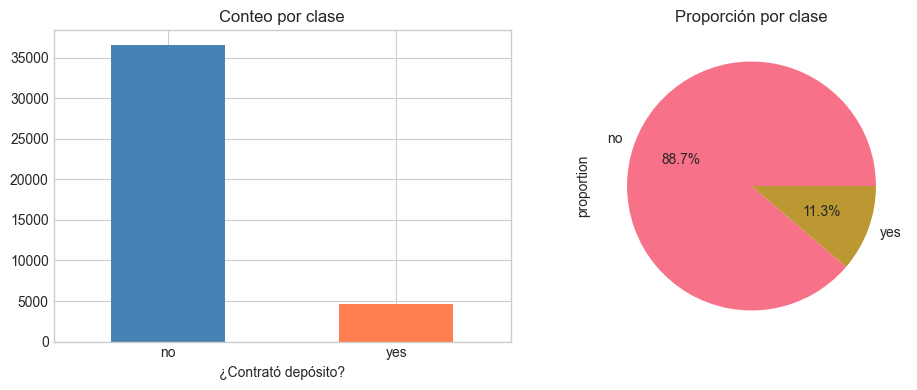

In [ ]:

print("Distribución de la variable objetivo (y):")
print(df['y'].value_counts())
print(f"\nProporción:\n{df['y'].value_counts(normalize=True).round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Conteo por clase')
axes[0].set_xlabel('¿Contrató depósito?')
axes[0].tick_params(axis='x', rotation=0)

df['y'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporción por clase')
plt.tight_layout()
plt.show()

### 2.3 Análisis de variables numéricas

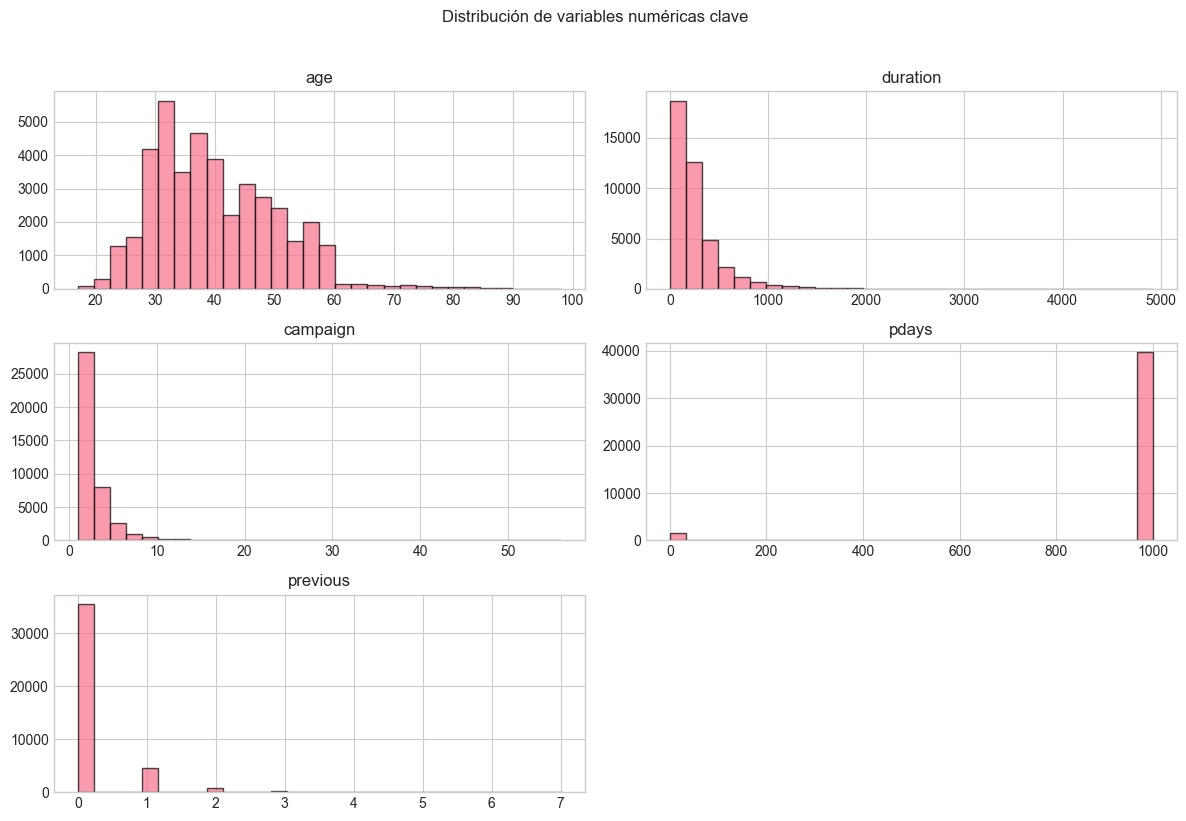

In [ ]:

key_numeric = ['age', 'duration', 'campaign', 'pdays', 'previous']
df[key_numeric].hist(bins=30, figsize=(12, 8), edgecolor='black', alpha=0.7)
plt.suptitle('Distribución de variables numéricas clave', y=1.02)
plt.tight_layout()
plt.show()

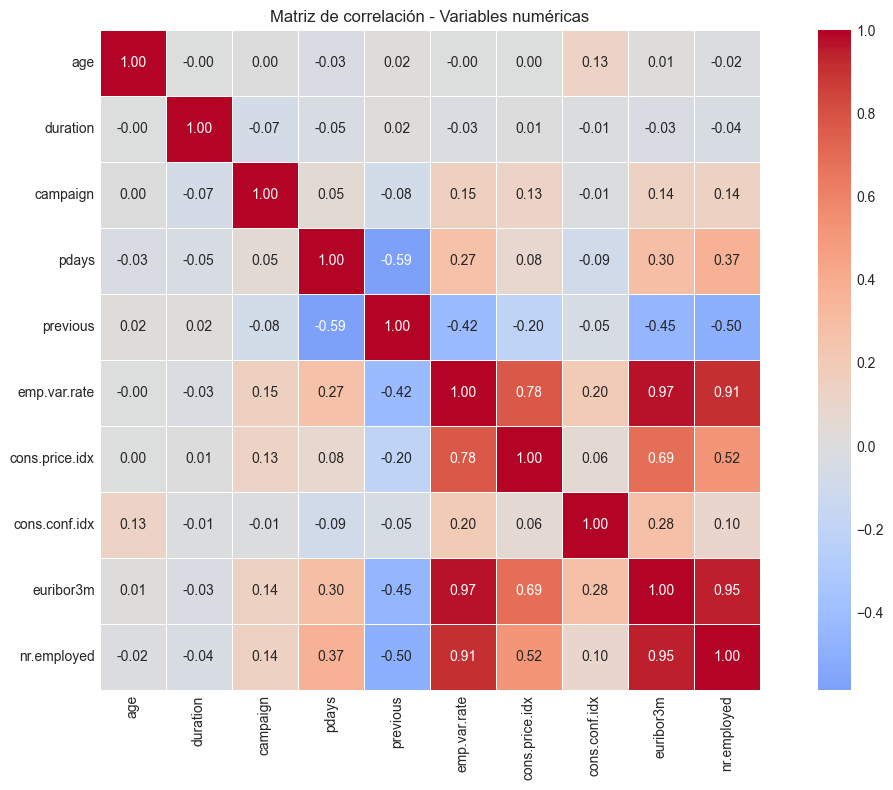

In [ ]:

plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Matriz de correlación - Variables numéricas')
plt.tight_layout()
plt.show()

### 2.4 Análisis de variables categóricas

In [ ]:

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categorías - {df[col].unique()[:5]}...")

job: 12 categorías - ['housemaid' 'services' 'admin.' 'blue-collar' 'technician']...
marital: 4 categorías - ['married' 'single' 'divorced' 'unknown']...
education: 8 categorías - ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course']...
default: 3 categorías - ['no' 'unknown' 'yes']...
housing: 3 categorías - ['no' 'yes' 'unknown']...
loan: 3 categorías - ['no' 'yes' 'unknown']...
contact: 2 categorías - ['telephone' 'cellular']...
month: 10 categorías - ['may' 'jun' 'jul' 'aug' 'oct']...
day_of_week: 5 categorías - ['mon' 'tue' 'wed' 'thu' 'fri']...
poutcome: 3 categorías - ['nonexistent' 'failure' 'success']...
y: 2 categorías - ['no' 'yes']...


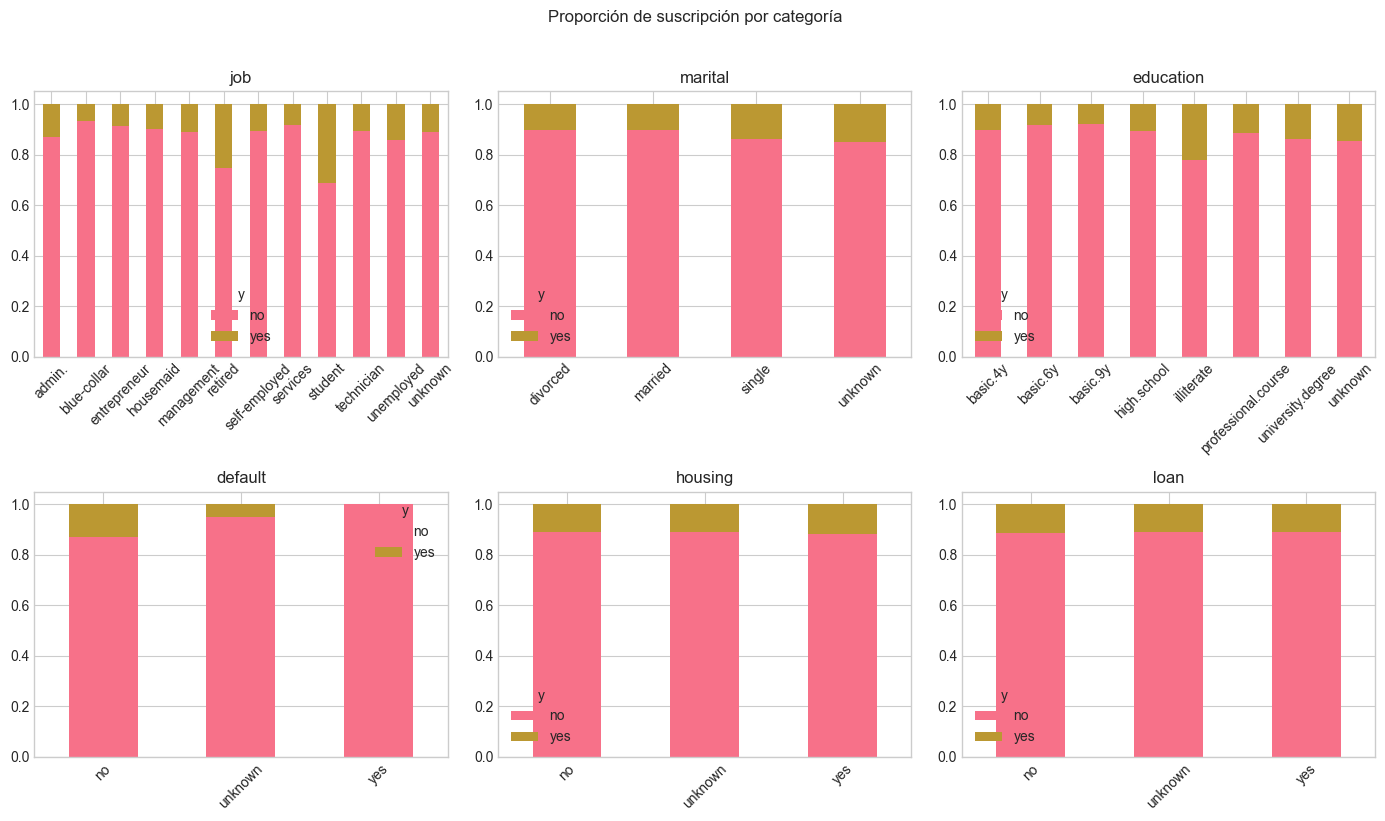

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols[:6]):
    pd.crosstab(df[col], df['y'], normalize='index').plot(kind='bar', ax=axes[i], stacked=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Proporción de suscripción por categoría', y=1.02)
plt.tight_layout()
plt.show()

### 2.5 Selección de variables y preparación de datos



In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


exclude_cols = ['duration', 'y']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y_target = df['y'].copy()


y_target = (y_target == 'yes').astype(int)


numeric_features = [c for c in numeric_cols if c not in exclude_cols]
categorical_features = [c for c in categorical_cols if c in X.columns]

print("Features numéricas:", numeric_features)
print("Features categóricas:", categorical_features)

Features numéricas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Features categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")
print(f"\nProporción target en train: {y_train.mean():.3f}")
print(f"Proporción target en test: {y_test.mean():.3f}")

Train: 32950 muestras
Test: 8238 muestras

Proporción target en train: 0.113
Proporción target en test: 0.113


## Paso 3: Modelo de Regresión Logística (configuración por defecto)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)


model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


model_lr.fit(X_train, y_train)


y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)
y_proba_test = model_lr.predict_proba(X_test)[:, 1]

print("=== Resultados en conjunto de entrenamiento ===")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train, zero_division=0):.4f}")
print(f"\n=== Resultados en conjunto de test ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_test, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

=== Resultados en conjunto de entrenamiento ===
Accuracy: 0.8999
Precision: 0.6620
Recall: 0.2284
F1-Score: 0.3397

=== Resultados en conjunto de test ===
Accuracy: 0.9014
Precision: 0.6933
Recall: 0.2241
F1-Score: 0.3388
ROC-AUC: 0.8007


Matriz de confusión (Test):
[[7218   92]
 [ 720  208]]

Reporte de clasificación (Test):
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7310
         Yes       0.69      0.22      0.34       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.64      8238
weighted avg       0.88      0.90      0.88      8238



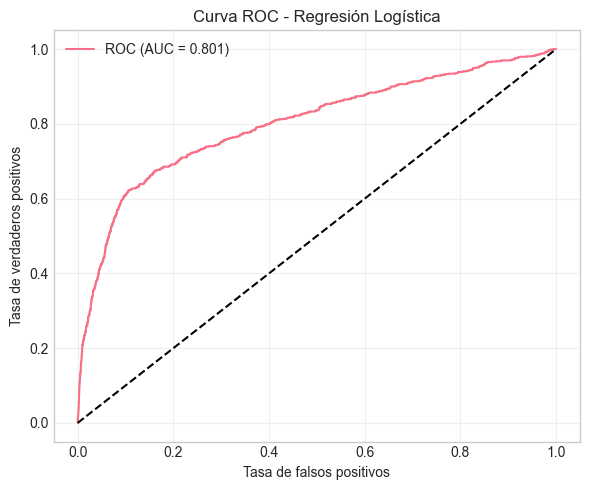

In [ ]:

print("Matriz de confusión (Test):")
print(confusion_matrix(y_test, y_pred_test))
print("\nReporte de clasificación (Test):")
print(classification_report(y_test, y_pred_test, target_names=['No', 'Yes']))


fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba_test):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Paso 4: Optimización del modelo



In [ ]:
from sklearn.model_selection import GridSearchCV


pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=2000))
])


param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced'],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__penalty': ['l2']
}


grid_search = GridSearchCV(
    pipe_lr, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)
print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Mejores parámetros: {'classifier__C': 10, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Mejor F1 (CV): 0.4505


C:\Users\Farmatodo Kike\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:

model_optimized = grid_search.best_estimator_
y_pred_opt = model_optimized.predict(X_test)
y_proba_opt = model_optimized.predict_proba(X_test)[:, 1]

print("=== Modelo optimizado - Resultados en Test ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_opt):.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_opt))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_opt, target_names=['No', 'Yes']))

=== Modelo optimizado - Resultados en Test ===
Accuracy: 0.8349
Precision: 0.3673
Recall: 0.6444
F1-Score: 0.4679
ROC-AUC: 0.8009

Matriz de confusión:
[[6280 1030]
 [ 330  598]]

Reporte de clasificación:
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      7310
         Yes       0.37      0.64      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.69      8238
weighted avg       0.88      0.83      0.85      8238



In [ ]:

comparison = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Modelo base': [
        accuracy_score(y_test, y_pred_test),
        precision_score(y_test, y_pred_test, zero_division=0),
        recall_score(y_test, y_pred_test, zero_division=0),
        f1_score(y_test, y_pred_test, zero_division=0),
        roc_auc_score(y_test, y_proba_test)
    ],
    'Modelo optimizado': [
        accuracy_score(y_test, y_pred_opt),
        precision_score(y_test, y_pred_opt, zero_division=0),
        recall_score(y_test, y_pred_opt, zero_division=0),
        f1_score(y_test, y_pred_opt, zero_division=0),
        roc_auc_score(y_test, y_proba_opt)
    ]
})
comparison['Mejora'] = comparison['Modelo optimizado'] - comparison['Modelo base']
print(comparison.to_string(index=False))

  Métrica  Modelo base  Modelo optimizado    Mejora
 Accuracy     0.901432           0.834911 -0.066521
Precision     0.693333           0.367322 -0.326011
   Recall     0.224138           0.644397  0.420259
 F1-Score     0.338762           0.467919  0.129156
  ROC-AUC     0.800715           0.800901  0.000186


## Conclusión

El modelo de regresión logística optimizado permite al banco identificar clientes con mayor probabilidad de contratar un depósito a largo plazo. El banco puede priorizar las llamadas de marketing hacia aquellos clientes con mayor probabilidad predicha, optimizando recursos y aumentando la tasa de conversión.